# Vehicle Detection — Evaluation only (no training)

This notebook **does not train any model**. It loads the four already-trained checkpoints
from Drive and reproduces the full evaluation pipeline:

- per-experiment metrics (overall + per-class) on the original and expanded test sets,
- training curves and confusion matrices (read from `runs/*/results.csv` and `*.png`),
- cross-experiment per-class charts,
- SAHI ablation on the Final weights.

**Runtime**: works on CPU (`Runtime → Change runtime type → CPU`) or any GPU. The device
is auto-detected. SAHI on CPU will take ~30–60 minutes; everything else is much faster.

**Prerequisites on Drive** (all under `MyDrive/vehicle_detection/vehicle-detection-project/`):

```
data.yaml
train/, val/, test/    (original close-up dataset)
runs/yolov8n_vehicle/weights/best.pt
runs/yolov8m_exp1/weights/best.pt
runs/yolov8n_expanded/weights/best.pt
runs/yolov8m_final/weights/best.pt
```

Just `Runtime → Run all`.

## 0. Setup

### 0.1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 0.2 — Install dependencies

In [2]:
!pip install ultralytics roboflow sahi -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.8/225.8 GB disk)


### 0.3 — Paths and device detection

In [3]:
import os, glob, random, shutil, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
from ultralytics import YOLO
from IPython.display import display

DATASET_PATH = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project'
DATA_YAML    = os.path.join(DATASET_PATH, 'data.yaml')
RUNS_DIR     = os.path.join(DATASET_PATH, 'runs')

assert os.path.exists(DATA_YAML), f'data.yaml not found: {DATA_YAML}'

# Patch data.yaml path for Colab
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
cfg['path'] = DATASET_PATH
COLAB_YAML = '/content/data.yaml'
with open(COLAB_YAML, 'w') as f:
    yaml.dump(cfg, f, sort_keys=False)

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Dataset path: {DATASET_PATH}')
print(f'Runs dir:     {RUNS_DIR}')

Device: cpu
Dataset path: /content/drive/MyDrive/vehicle_detection/vehicle-detection-project
Runs dir:     /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs


### 0.4 — Locate trained weights on Drive

All four `best.pt` files must already exist. If anything is `MISSING`, you have to train
that model first (in the main `vehicle_detection_pipeline.ipynb`).

In [4]:
WEIGHTS_BASELINE = f'{RUNS_DIR}/yolov8n_vehicle/weights/best.pt'
WEIGHTS_EXP1     = f'{RUNS_DIR}/yolov8m_exp1/weights/best.pt'
WEIGHTS_EXP2     = f'{RUNS_DIR}/yolov8n_expanded/weights/best.pt'
WEIGHTS_FINAL    = f'{RUNS_DIR}/yolov8m_final/weights/best.pt'

BASELINE_RUN_DIR = f'{RUNS_DIR}/yolov8n_vehicle'
EXP1_RUN_DIR     = f'{RUNS_DIR}/yolov8m_exp1'
EXP2_RUN_DIR     = f'{RUNS_DIR}/yolov8n_expanded'
FINAL_RUN_DIR    = f'{RUNS_DIR}/yolov8m_final'

print('Trained weights on Drive:')
ok = True
for name, path in [('Baseline', WEIGHTS_BASELINE), ('Exp1', WEIGHTS_EXP1),
                   ('Exp2',     WEIGHTS_EXP2),     ('Final', WEIGHTS_FINAL)]:
    exists = os.path.exists(path)
    ok &= exists
    print(f'  {name:8s}: {"OK" if exists else "MISSING"}  {path}')

assert ok, 'Some weights are missing on Drive — train the missing models first.'

Trained weights on Drive:
  Baseline: OK  /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8n_vehicle/weights/best.pt
  Exp1    : OK  /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8m_exp1/weights/best.pt
  Exp2    : OK  /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8n_expanded/weights/best.pt
  Final   : OK  /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8m_final/weights/best.pt


### 0.5 — Helper functions (training curves, per-class metrics, charts)

In [5]:
def plot_training_curves(run_dir, title):
    csv_path = os.path.join(run_dir, 'results.csv')
    if not os.path.exists(csv_path):
        print(f'No results.csv in {run_dir}')
        return
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for col in ['train/box_loss', 'train/cls_loss', 'val/box_loss', 'val/cls_loss']:
        if col in df.columns:
            axes[0].plot(df['epoch'], df[col], label=col)
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].set_title(f'{title} — losses')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    for col in ['metrics/precision(B)', 'metrics/recall(B)',
                'metrics/mAP50(B)', 'metrics/mAP50-95(B)']:
        if col in df.columns:
            axes[1].plot(df['epoch'], df[col], label=col.replace('metrics/', '').replace('(B)', ''))
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('score')
    axes[1].set_title(f'{title} — metrics')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def show_confusion_matrix(run_dir, title):
    for name in ['confusion_matrix_normalized.png', 'confusion_matrix.png']:
        p = os.path.join(run_dir, name)
        if os.path.exists(p):
            fig, ax = plt.subplots(figsize=(7, 7))
            ax.imshow(mpimg.imread(p))
            ax.set_title(f'{title} — {name}'); ax.axis('off')
            plt.show()
            return
    print(f'No confusion matrix found in {run_dir}')


def per_class_metrics(model, data_yaml, split='test'):
    res = model.val(data=data_yaml, split=split, verbose=False, device=DEVICE)
    names = model.names
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names)]

    rows = []
    for i in range(len(names)):
        try:
            p, r, ap50, ap = res.box.class_result(i)
        except Exception:
            p   = float(res.box.p[i])    if hasattr(res.box, 'p')    and i < len(res.box.p)    else float('nan')
            r   = float(res.box.r[i])    if hasattr(res.box, 'r')    and i < len(res.box.r)    else float('nan')
            ap50= float(res.box.ap50[i]) if hasattr(res.box, 'ap50') and i < len(res.box.ap50) else float('nan')
            ap  = float(res.box.ap[i])   if hasattr(res.box, 'ap')   and i < len(res.box.ap)   else float('nan')
        rows.append({
            'class': names[i],
            'Precision': float(p),
            'Recall': float(r),
            'mAP@0.5': float(ap50),
            'mAP@0.5:0.95': float(ap),
        })
    return pd.DataFrame(rows)


def plot_per_class(df, title):
    metrics = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95']
    x = np.arange(len(df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, m in enumerate(metrics):
        ax.bar(x + (i - 1.5) * width, df[m], width, label=m)
    ax.set_xticks(x); ax.set_xticklabels(df['class'])
    ax.set_ylim(0, 1.05); ax.set_ylabel('score'); ax.set_title(title)
    ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_grouped_per_class(per_class_dfs, metric, title, ylim=(0, 1.05)):
    classes = list(per_class_dfs.values())[0]['class'].tolist()
    x = np.arange(len(classes))
    n = len(per_class_dfs)
    width = 0.8 / n
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (name, df) in enumerate(per_class_dfs.items()):
        if metric not in df.columns:
            continue
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, df[metric].astype(float), width, label=name)
    ax.set_xticks(x); ax.set_xticklabels(classes)
    ax.set_ylim(*ylim); ax.set_ylabel(metric); ax.set_title(title)
    ax.legend(loc='lower right', fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

## Part 1 — Baseline (YOLOv8n, original test)

In [6]:
model_baseline = YOLO(WEIGHTS_BASELINE)

### 1.1 — Training curves

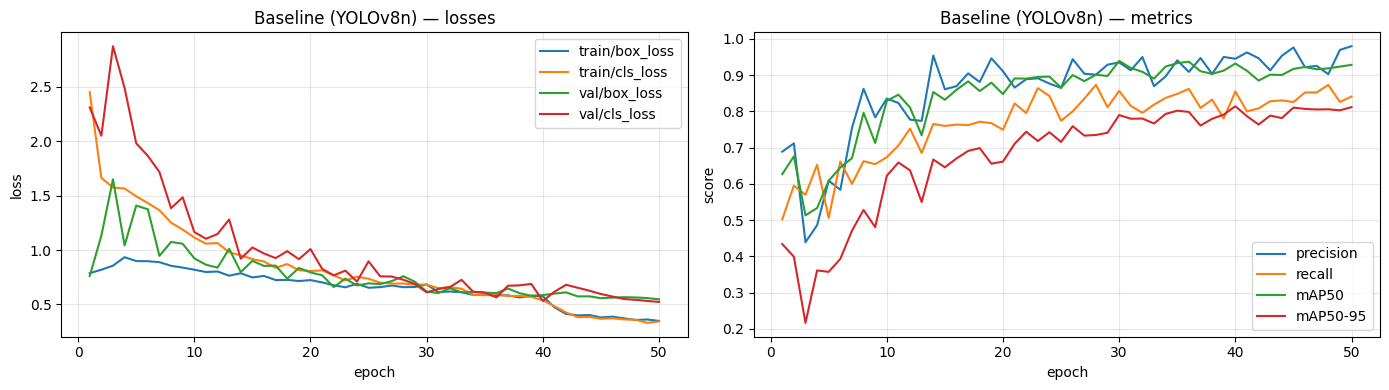

In [7]:
plot_training_curves(BASELINE_RUN_DIR, 'Baseline (YOLOv8n)')

### 1.2 — Evaluate on val and test

In [8]:
val_res_baseline  = model_baseline.val(data=COLAB_YAML, split='val',  verbose=False, device=DEVICE)
test_res_baseline = model_baseline.val(data=COLAB_YAML, split='test', verbose=False, device=DEVICE)

print('=== Baseline on val ===')
print(f'  mAP@0.5:      {val_res_baseline.box.map50:.4f}')
print(f'  mAP@0.5:0.95: {val_res_baseline.box.map:.4f}')
print(f'  Precision:    {val_res_baseline.box.mp:.4f}')
print(f'  Recall:       {val_res_baseline.box.mr:.4f}')
print('=== Baseline on test ===')
print(f'  mAP@0.5:      {test_res_baseline.box.map50:.4f}')
print(f'  mAP@0.5:0.95: {test_res_baseline.box.map:.4f}')
print(f'  Precision:    {test_res_baseline.box.mp:.4f}')
print(f'  Recall:       {test_res_baseline.box.mr:.4f}')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.8 ms, read: 0.2±0.1 MB/s, size: 65.1 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/val/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 9.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 18.9s/it 1:35
                   all         80         97      0.945      0.855      0.932      0.814
Speed: 7.1ms preprocess, 326.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 1.1±0.6 ms, read: 0.2±0.0 MB/s, size: 49.9 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-proj

### 1.3 — Per-class metrics (baseline on test)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 1.0±0.4 ms, read: 26.1±13.9 MB/s, size: 67.9 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 19.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 5.1s/it 25.3s
                   all         80         96      0.963      0.898      0.932      0.792
Speed: 6.6ms preprocess, 287.2ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val-3


,class,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,bus,0.9919,0.8929,0.8950,0.8109
1,car,0.8783,0.7143,0.8421,0.7459
2,motorcycle,0.9836,1.0000,0.9950,0.7277
3,truck,1.0000,0.9846,0.9950,0.8819


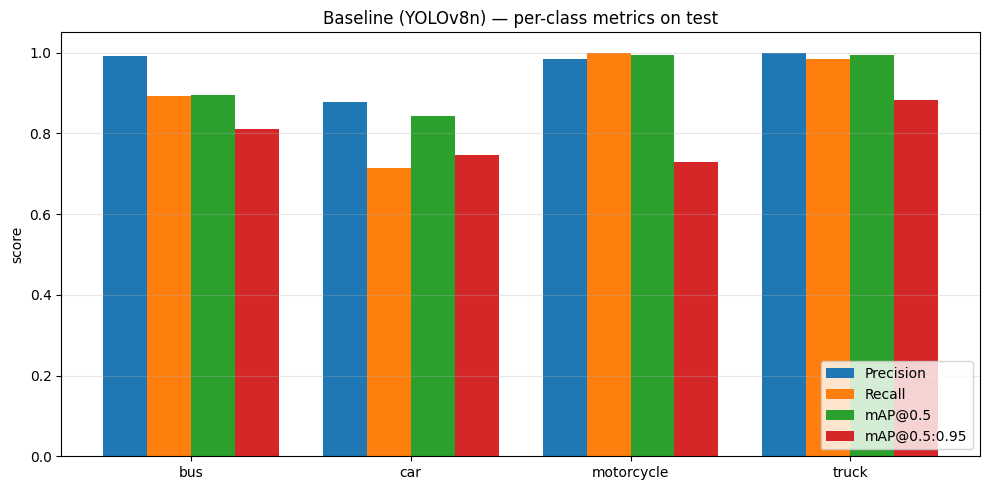

In [9]:
df_baseline_per_class = per_class_metrics(model_baseline, COLAB_YAML, split='test')
display(df_baseline_per_class.round(4))
plot_per_class(df_baseline_per_class, 'Baseline (YOLOv8n) — per-class metrics on test')

### 1.4 — Confusion matrix (baseline)

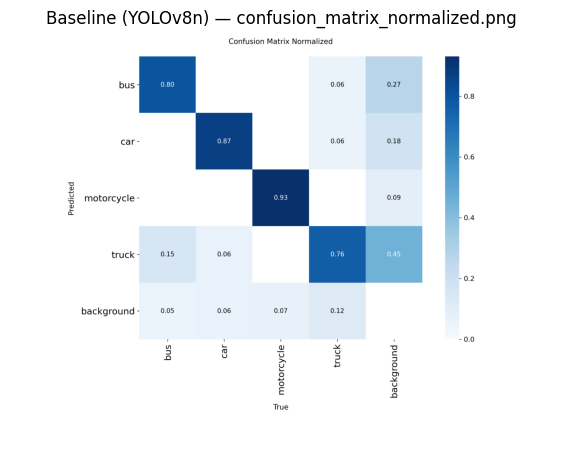

In [10]:
show_confusion_matrix(BASELINE_RUN_DIR, 'Baseline (YOLOv8n)')

### 1.5 — Visualise a few baseline predictions

Results saved to /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/predictions_baseline/test_predictions


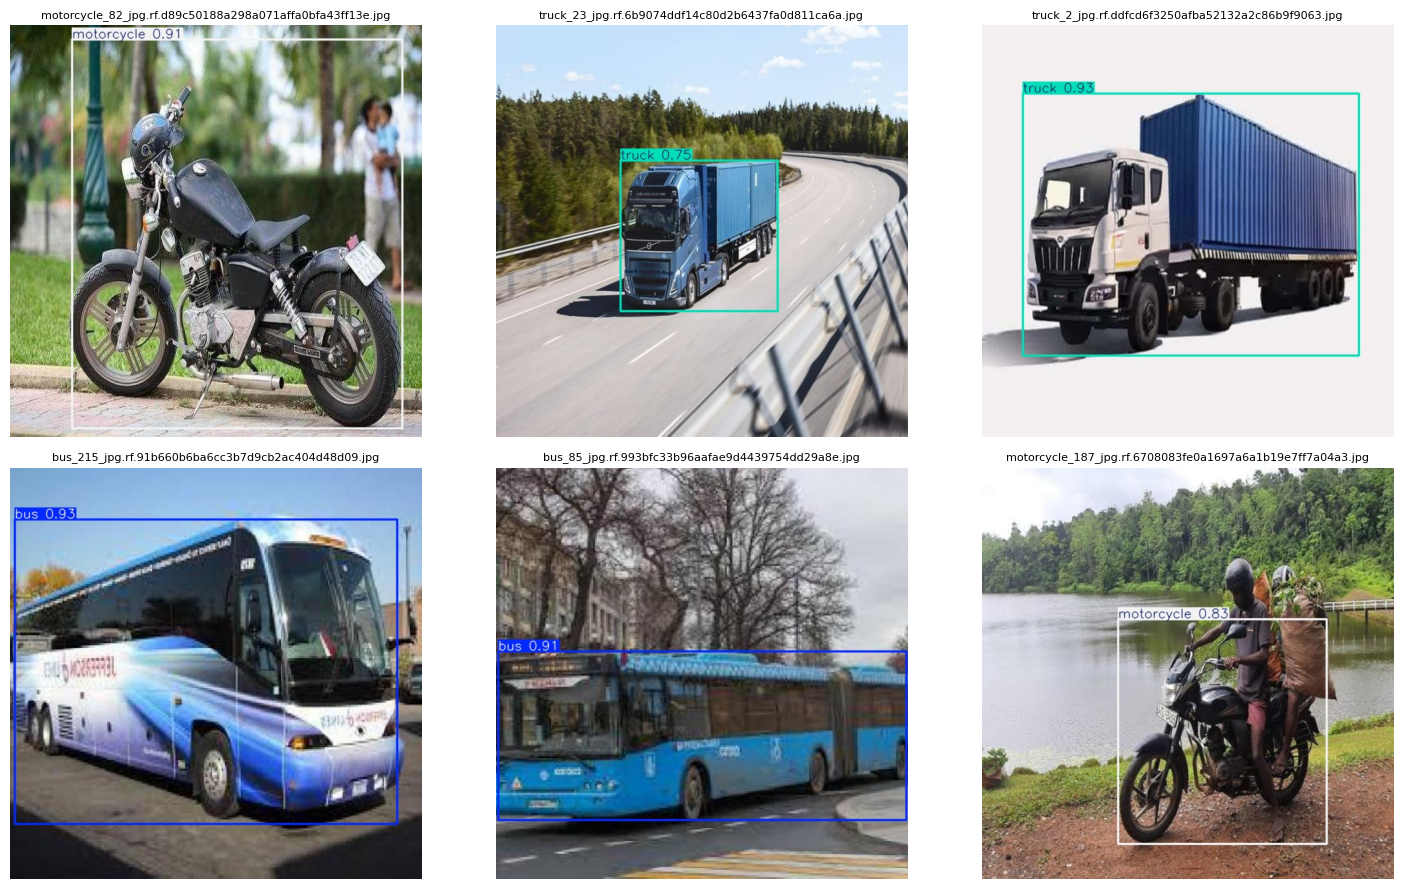

In [11]:
TEST_IMAGES = os.path.join(DATASET_PATH, 'test', 'images')
PRED_OUT_DIR = os.path.join(RUNS_DIR, 'predictions_baseline')
os.makedirs(PRED_OUT_DIR, exist_ok=True)

model_baseline.predict(
    source=TEST_IMAGES, save=True,
    project=PRED_OUT_DIR, name='test_predictions', exist_ok=True,
    verbose=False, device=DEVICE,
)

pred_imgs = sorted(glob.glob(f'{PRED_OUT_DIR}/test_predictions/*.jpg'))
random.seed(44)
samples = random.sample(pred_imgs, min(6, len(pred_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, p in zip(axes.flat, samples):
    ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(os.path.basename(p), fontsize=8)
plt.tight_layout(); plt.show()

## Part 2 — Experiment 1 (YOLOv8m, original test)

In [12]:
model_exp1 = YOLO(WEIGHTS_EXP1)
test_res_exp1 = model_exp1.val(data=COLAB_YAML, split='test', verbose=False, device=DEVICE)

comparison_1 = pd.DataFrame({
    'Metric':              ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'Baseline (Nano)':     [test_res_baseline.box.map50, test_res_baseline.box.map,
                            test_res_baseline.box.mp,    test_res_baseline.box.mr],
    'Exp 1 (Medium)':      [test_res_exp1.box.map50,     test_res_exp1.box.map,
                            test_res_exp1.box.mp,        test_res_exp1.box.mr],
}).round(4)
display(comparison_1)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 24.4±8.8 MB/s, size: 46.9 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 13.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 36.2s/it 3:01
                   all         80         96      0.975      0.867      0.939      0.812
Speed: 9.0ms preprocess, 2229.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val-4


,Metric,Baseline (Nano),Exp 1 (Medium)
0,mAP@0.5,0.9318,0.9393
1,mAP@0.5:0.95,0.7916,0.8122
2,Precision,0.9635,0.9747
3,Recall,0.8979,0.8666


### 2.1 — Per-class metrics — Experiment 1

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 29.6±12.9 MB/s, size: 65.0 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 15.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 34.7s/it 2:54
                   all         80         96      0.975      0.867      0.939      0.812
Speed: 7.8ms preprocess, 2135.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-5


,class,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,bus,1.0000,0.8322,0.9120,0.8576
1,car,0.9278,0.7143,0.8584,0.7936
2,motorcycle,0.9864,1.0000,0.9950,0.7085
3,truck,0.9847,0.9200,0.9919,0.8890


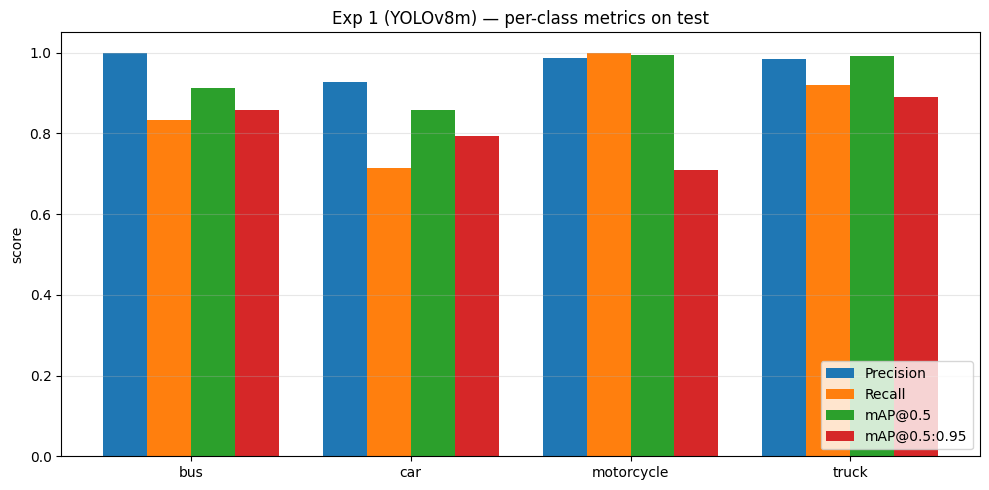

In [13]:
df_exp1_per_class = per_class_metrics(model_exp1, COLAB_YAML, split='test')
display(df_exp1_per_class.round(4))
plot_per_class(df_exp1_per_class, 'Exp 1 (YOLOv8m) — per-class metrics on test')

### 2.2 — Training curves and confusion matrix — Experiment 1

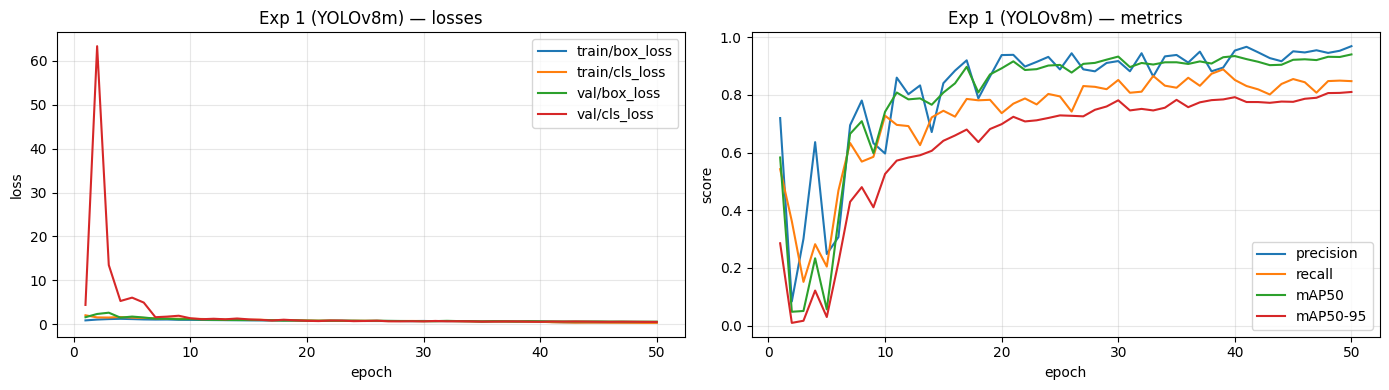

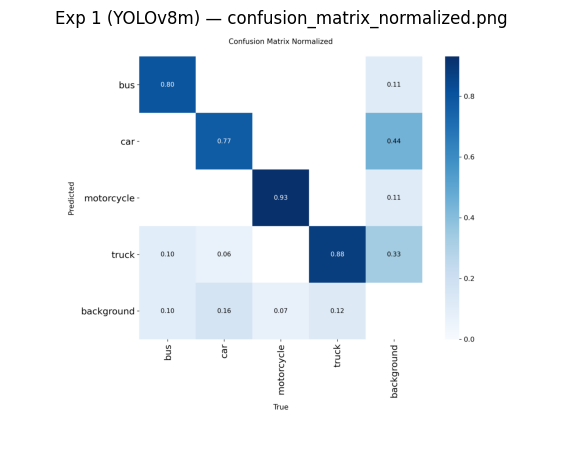

In [14]:
plot_training_curves(EXP1_RUN_DIR, 'Exp 1 (YOLOv8m)')
show_confusion_matrix(EXP1_RUN_DIR, 'Exp 1 (YOLOv8m)')

## Part 3 — Rebuild balanced expanded dataset + evaluate Experiment 2

The expanded dataset lives in `/content/expanded_dataset/` (Colab local disk), so it is
gone whenever the runtime restarts. We rebuild it here from Drive + Roboflow. No GPU
needed for this section (only file copies).

### 3.1 — Download Roboflow + build dynamic class mapping

In [15]:
from roboflow import Roboflow

rf = Roboflow(api_key='Wfetji1eTEiH7q2T4F1I')
project = rf.workspace('traffic-camera').project('vehicles-22g3b')
version = project.version(7)
new_ds = version.download('yolov8')

with open(os.path.join(new_ds.location, 'data.yaml')) as f:
    rf_cfg = yaml.safe_load(f)

rf_names_raw = rf_cfg['names']
if isinstance(rf_names_raw, list):
    rf_names = {i: n for i, n in enumerate(rf_names_raw)}
else:
    rf_names = {int(k): v for k, v in rf_names_raw.items()}

target_classes = {'bus': 0, 'car': 1, 'motorcycle': 2, 'truck': 3}
class_map = {rf_id: target_classes[name]
             for rf_id, name in rf_names.items()
             if name in target_classes}

print('Roboflow classes:        ', rf_names)
print('Class mapping (rf -> us):', class_map)
skipped = [n for i, n in rf_names.items() if i not in class_map]
if skipped:
    print('Skipped (not in targets):', skipped)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vehicles-7 in yolov8:: 100%|██████████| 1740/1740 [00:01<00:00, 1317.65it/s]


Roboflow classes:         {0: 'bus', 1: 'car', 2: 'motorcycle', 3: 'truck', 4: 'xbicycle'}
Class mapping (rf -> us): {0: 0, 1: 1, 2: 2, 3: 3}
Skipped (not in targets): ['xbicycle']


### 3.2 — Build balanced expanded dataset

Equal number of `bl_` (baseline) and `rf_` (Roboflow) images in every split.

In [16]:
EXPANDED_DATASET_DIR = '/content/expanded_dataset'
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(EXPANDED_DATASET_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(EXPANDED_DATASET_DIR, split, 'labels'), exist_ok=True)

IMG_EXTS = ('.jpg', '.jpeg', '.png')


def count_baseline(split):
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    return sum(1 for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS))


target_counts = {split: count_baseline(split) for split in ['train', 'val', 'test']}
print('Target counts per split (baseline = Roboflow):', target_counts)


def collect_roboflow_pool():
    pool = []
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(new_ds.location, split, 'images')
        lbl_dir = os.path.join(new_ds.location, split, 'labels')
        if not os.path.exists(img_dir):
            continue
        for img_name in os.listdir(img_dir):
            if not img_name.lower().endswith(IMG_EXTS):
                continue
            lbl_name = os.path.splitext(img_name)[0] + '.txt'
            lbl_path = os.path.join(lbl_dir, lbl_name)
            remapped = []
            if os.path.exists(lbl_path):
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.split()
                        if not parts:
                            continue
                        cls_id = int(parts[0])
                        if cls_id in class_map:
                            parts[0] = str(class_map[cls_id])
                            remapped.append(' '.join(parts))
            if remapped:
                pool.append((os.path.join(img_dir, img_name), remapped))
    return pool


rf_pool = collect_roboflow_pool()
print(f'Eligible Roboflow images: {len(rf_pool)}')

random.seed(42)
random.shuffle(rf_pool)

selected = {}
cursor = 0
for split in ['train', 'val', 'test']:
    want = target_counts[split]
    take = rf_pool[cursor:cursor + want]
    selected[split] = take
    cursor += len(take)
    if len(take) < want:
        print(f'  WARNING: split={split} wanted {want} Roboflow imgs, got {len(take)}')


def copy_baseline_split(split):
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    dst_img = os.path.join(EXPANDED_DATASET_DIR, split, 'images')
    dst_lbl = os.path.join(EXPANDED_DATASET_DIR, split, 'labels')
    n = 0
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(IMG_EXTS):
            continue
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        shutil.copy(os.path.join(img_dir, img_name),
                    os.path.join(dst_img, f'bl_{split}_{img_name}'))
        src_lbl = os.path.join(lbl_dir, lbl_name)
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, os.path.join(dst_lbl, f'bl_{split}_{lbl_name}'))
        n += 1
    return n


def write_roboflow_split(split, items):
    dst_img = os.path.join(EXPANDED_DATASET_DIR, split, 'images')
    dst_lbl = os.path.join(EXPANDED_DATASET_DIR, split, 'labels')
    for img_path, lines in items:
        img_name = os.path.basename(img_path)
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        shutil.copy(img_path, os.path.join(dst_img, f'rf_{split}_{img_name}'))
        with open(os.path.join(dst_lbl, f'rf_{split}_{lbl_name}'), 'w') as f:
            f.write('\n'.join(lines) + '\n')


print('\nFinal split counts:')
for split in ['train', 'val', 'test']:
    n_bl = copy_baseline_split(split)
    write_roboflow_split(split, selected[split])
    n_rf = len(selected[split])
    print(f'  {split:5s}: {n_bl} baseline + {n_rf} roboflow = {n_bl + n_rf}')


expanded_yaml = {
    'path':  EXPANDED_DATASET_DIR,
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'names': {0: 'bus', 1: 'car', 2: 'motorcycle', 3: 'truck'},
}
EXPANDED_YAML_PATH = '/content/expanded_data.yaml'
with open(EXPANDED_YAML_PATH, 'w') as f:
    yaml.dump(expanded_yaml, f, sort_keys=False)

print('\nWrote', EXPANDED_YAML_PATH)

Target counts per split (baseline = Roboflow): {'train': 714, 'val': 80, 'test': 80}
Eligible Roboflow images: 854

Final split counts:
  train: 714 baseline + 714 roboflow = 1428
  val  : 80 baseline + 80 roboflow = 160
  test : 80 baseline + 60 roboflow = 140

Wrote /content/expanded_data.yaml


### 3.3 — Baseline vs Experiment 2 on the expanded test set

In [17]:
model_exp2 = YOLO(WEIGHTS_EXP2)

baseline_on_expanded = model_baseline.val(data=EXPANDED_YAML_PATH, split='test', verbose=False, device=DEVICE)
exp2_on_expanded     = model_exp2.val   (data=EXPANDED_YAML_PATH, split='test', verbose=False, device=DEVICE)

comparison_2 = pd.DataFrame({
    'Metric':                  ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'Baseline (Nano)':         [baseline_on_expanded.box.map50, baseline_on_expanded.box.map,
                                baseline_on_expanded.box.mp,    baseline_on_expanded.box.mr],
    'Exp 2 (Nano + Roboflow)': [exp2_on_expanded.box.map50,     exp2_on_expanded.box.map,
                                exp2_on_expanded.box.mp,        exp2_on_expanded.box.mr],
}).round(4)
display(comparison_2)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1490.2±605.9 MB/s, size: 128.4 KB)
val: Scanning /content/expanded_dataset/test/labels... 140 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 1.6Kit/s 0.1s
val: New cache created: /content/expanded_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.4s/it 39.5s
                   all        140        669      0.725      0.416      0.467      0.378
Speed: 4.8ms preprocess, 257.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val-6
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1184.7±354.3 MB/s, size: 54.4 KB)
val: Scanning /content/expanded_dataset

,Metric,Baseline (Nano),Exp 2 (Nano + Roboflow)
0,mAP@0.5,0.4668,0.9541
1,mAP@0.5:0.95,0.3781,0.8104
2,Precision,0.7247,0.9358
3,Recall,0.4158,0.8999


### 3.4 — Per-class metrics — Experiment 2

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1909.3±442.3 MB/s, size: 72.1 KB)
val: Scanning /content/expanded_dataset/test/labels.cache... 140 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 39.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.4s/it 39.8s
                   all        140        669      0.936        0.9      0.954       0.81
Speed: 5.2ms preprocess, 254.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val-8


,class,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,bus,0.9255,0.8684,0.9336,0.8331
1,car,0.9429,0.8738,0.9414,0.8179
2,motorcycle,0.9415,0.8737,0.9549,0.6866
3,truck,0.9333,0.9839,0.9864,0.9039


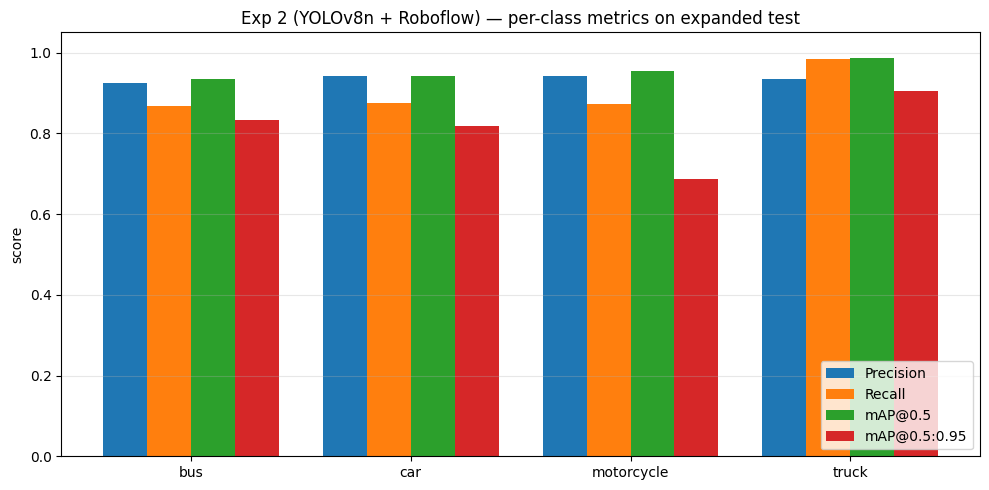

In [18]:
df_exp2_per_class = per_class_metrics(model_exp2, EXPANDED_YAML_PATH, split='test')
display(df_exp2_per_class.round(4))
plot_per_class(df_exp2_per_class, 'Exp 2 (YOLOv8n + Roboflow) — per-class metrics on expanded test')

### 3.5 — Training curves and confusion matrix — Experiment 2

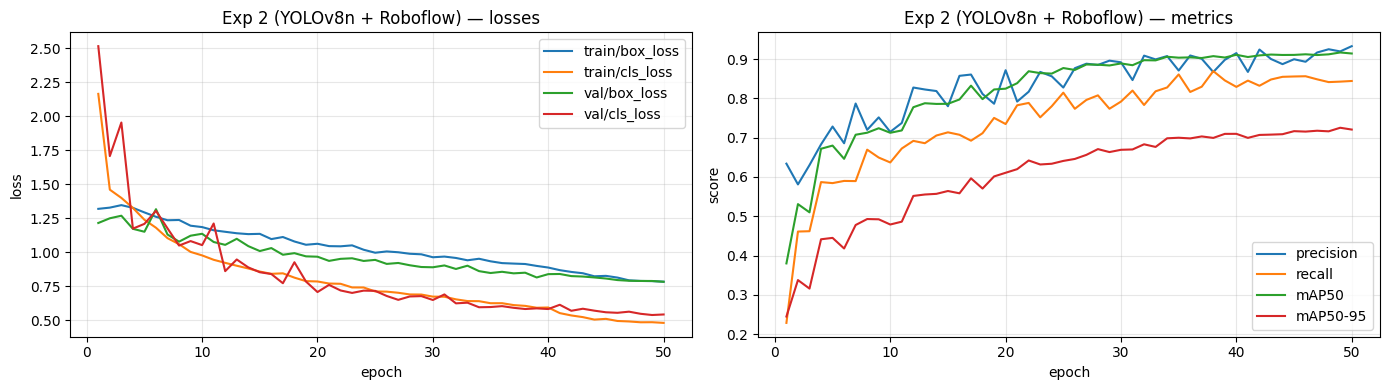

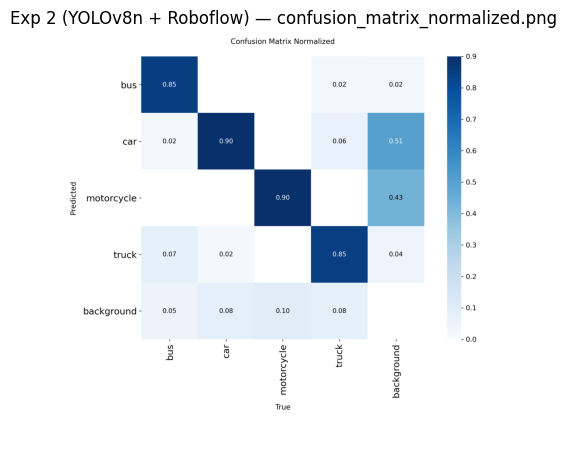

In [19]:
plot_training_curves(EXP2_RUN_DIR, 'Exp 2 (YOLOv8n + Roboflow)')
show_confusion_matrix(EXP2_RUN_DIR, 'Exp 2 (YOLOv8n + Roboflow)')

## Part 4 — Final model: YOLOv8m on the balanced expanded dataset

This is our best trained configuration (no SAHI here — that is Part 5).

### 4.2 — Re-evaluate all four trained models on the expanded test set

In [21]:
models_info = {
    'Baseline (Nano)':       WEIGHTS_BASELINE,
    'Exp 1 (Medium)':        WEIGHTS_EXP1,
    'Exp 2 (Nano+Extra)':    WEIGHTS_EXP2,
    'Final (Medium+Extra)':  WEIGHTS_FINAL,
}

per_class_by_model = {}
rows = []
for name, weights in models_info.items():
    print(f'Evaluating {name} ...')
    m = YOLO(weights)
    res = m.val(data=EXPANDED_YAML_PATH, split='test', verbose=False, device=DEVICE)
    rows.append({
        'Model':         name,
        'mAP@0.5':       round(res.box.map50, 4),
        'mAP@0.5:0.95':  round(res.box.map,   4),
        'Precision':     round(res.box.mp,    4),
        'Recall':        round(res.box.mr,    4),
    })
    per_class_by_model[name] = per_class_metrics(m, EXPANDED_YAML_PATH, split='test')

df_trained = pd.DataFrame(rows)
print('\n=== Trained-model comparison on the balanced expanded test set ===')
display(df_trained)
df_trained.to_csv(os.path.join(RUNS_DIR, 'trained_models_comparison.csv'), index=False)

Evaluating Baseline (Nano) ...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1487.2±611.3 MB/s, size: 110.6 KB)
val: Scanning /content/expanded_dataset/test/labels.cache... 140 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 30.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.4s/it 39.5s
                   all        140        669      0.725      0.416      0.467      0.378
Speed: 5.9ms preprocess, 253.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val-12
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1405.2±794.8 MB/s, size: 56.3 KB)
val: Scanning /content/expanded_dataset/test/labels.cache... 140 ima

,Model,mAP@0.5,mAP@0.5:0.95,Precision,Recall
0,Baseline (Nano),0.4668,0.3781,0.7247,0.4158
1,Exp 1 (Medium),0.4502,0.3813,0.6890,0.4082
2,Exp 2 (Nano+Extra),0.9541,0.8104,0.9358,0.8999
3,Final (Medium+Extra),0.9650,0.8677,0.9708,0.9298


### 4.3 — Per-class metrics — Final model

,class,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,bus,1.0000,0.9023,0.9250,0.8673
1,car,0.9886,0.9202,0.9604,0.8820
2,motorcycle,0.9705,0.9289,0.9838,0.7980
3,truck,0.9239,0.9677,0.9906,0.9236


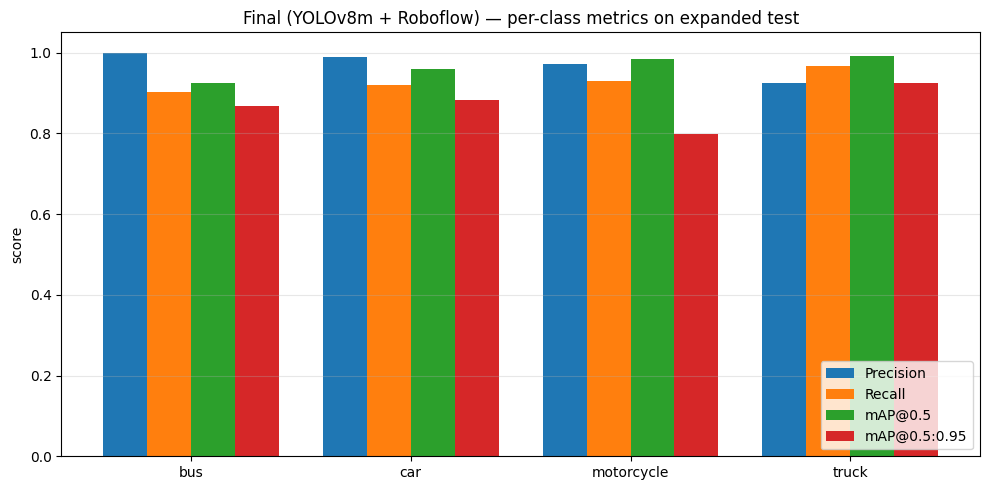

In [22]:
df_final_per_class = per_class_by_model['Final (Medium+Extra)']
display(df_final_per_class.round(4))
plot_per_class(df_final_per_class, 'Final (YOLOv8m + Roboflow) — per-class metrics on expanded test')

### 4.4 — Training curves and confusion matrix — Final model

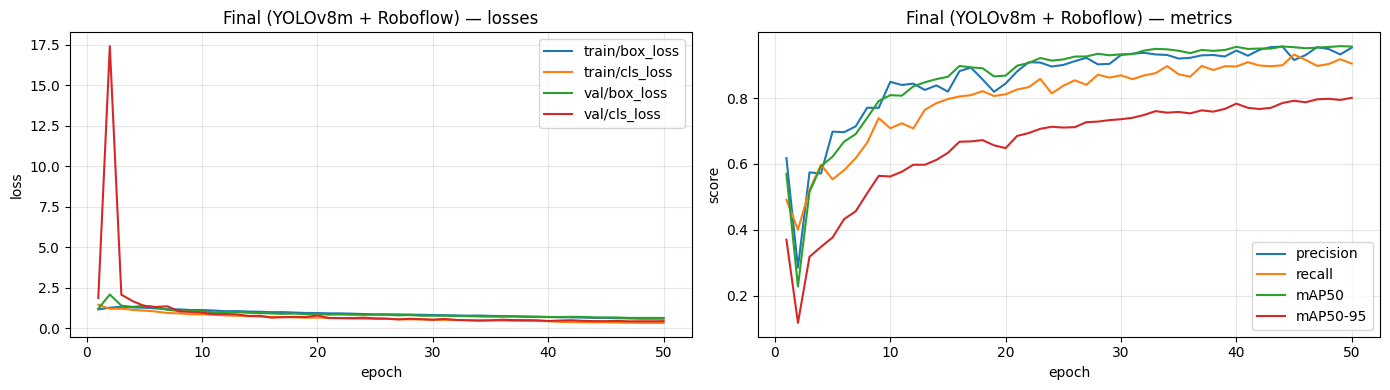

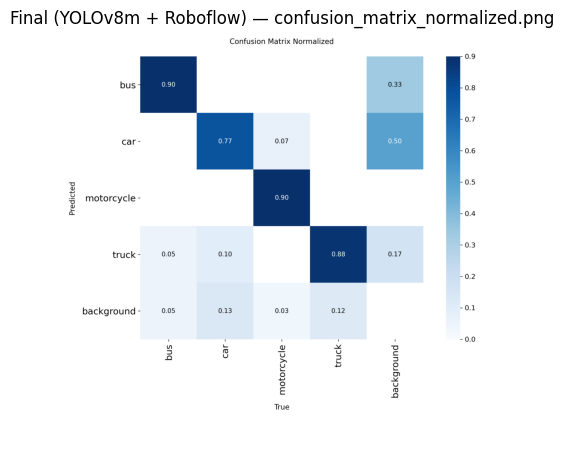

In [23]:
plot_training_curves(FINAL_RUN_DIR, 'Final (YOLOv8m + Roboflow)')
show_confusion_matrix(FINAL_RUN_DIR, 'Final (YOLOv8m + Roboflow)')

### 4.5 — Per-class comparison across the four trained models

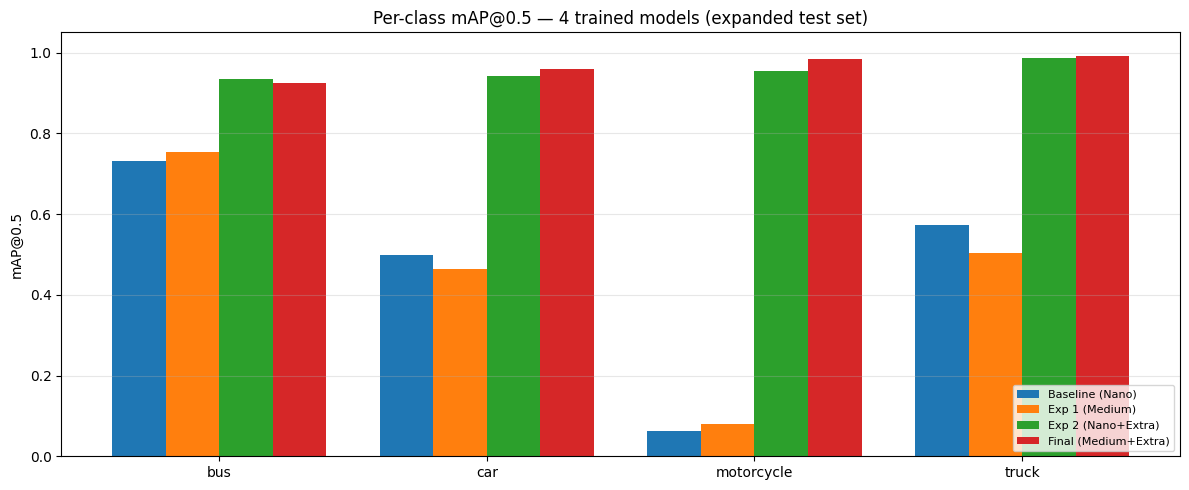

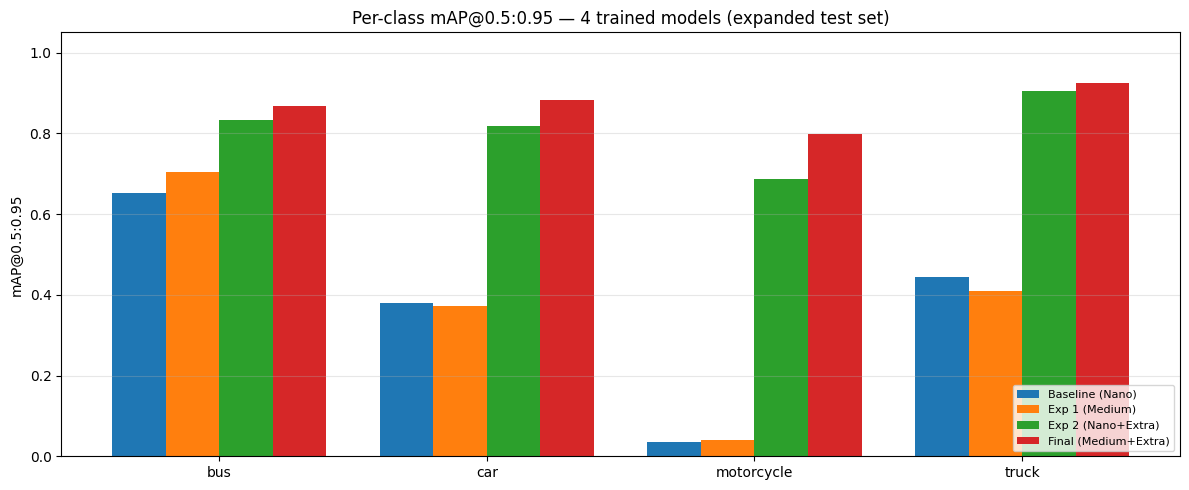

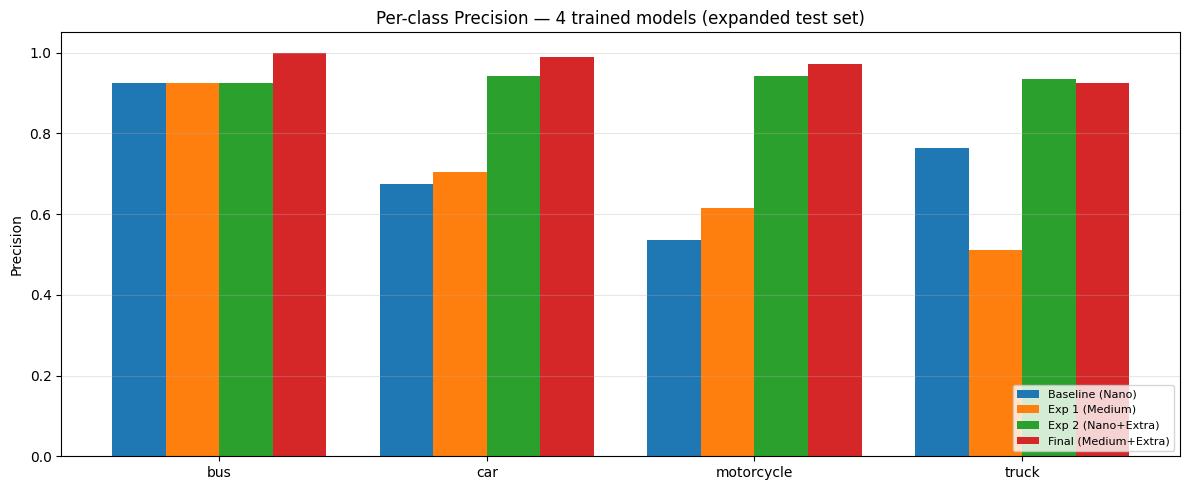

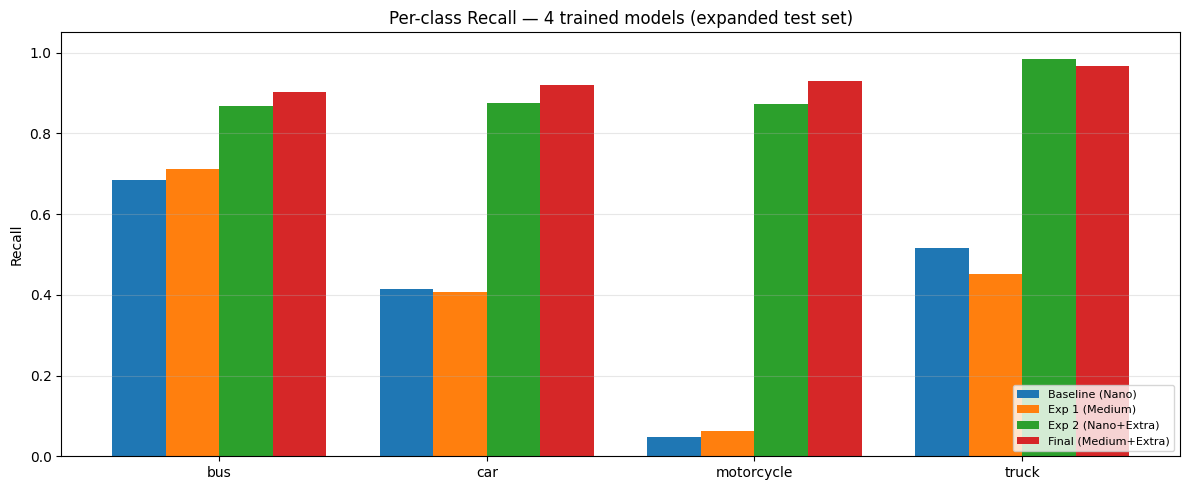

In [24]:
for metric in ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']:
    plot_grouped_per_class(
        per_class_by_model,
        metric,
        f'Per-class {metric} — 4 trained models (expanded test set)',
    )

## Part 5 — SAHI ablation (separate inference-time technique)

Loads the **Final weights** and runs sliced inference. **This is the slowest step on CPU**
(~30–60 minutes for ~160 test images at slice 640x640).

### 5.1 — Install SAHI and load the Final weights as a SAHI detection model

In [25]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from PIL import Image

detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=WEIGHTS_FINAL,
    confidence_threshold=0.45,
    device=DEVICE,
)


def compute_iou(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter  = max(0, x2 - x1) * max(0, y2 - y1)
    union  = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
    return inter / union if union > 0 else 0


def yolo_to_xyxy(cx, cy, w, h, W, H):
    return [(cx - w/2)*W, (cy - h/2)*H, (cx + w/2)*W, (cy + h/2)*H]

### 5.2 — SAHI per-class metrics on the expanded test set

Class-aware matching: TP requires same class AND IoU >= 0.5.

In [26]:
CLASS_NAMES = ['bus', 'car', 'motorcycle', 'truck']
NC = len(CLASS_NAMES)

test_images = sorted(
    glob.glob(os.path.join(EXPANDED_DATASET_DIR, 'test', 'images', '*.jpg')) +
    glob.glob(os.path.join(EXPANDED_DATASET_DIR, 'test', 'images', '*.png'))
)
label_dir = os.path.join(EXPANDED_DATASET_DIR, 'test', 'labels')

tp = [0]*NC; fp = [0]*NC; fn = [0]*NC

for idx, img_path in enumerate(test_images):
    if idx % 20 == 0:
        print(f'  SAHI: {idx}/{len(test_images)}')
    img = Image.open(img_path); W, H = img.size

    res = get_sliced_prediction(
        img_path, detection_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.1, overlap_width_ratio=0.1,
    )

    lbl_path = os.path.join(label_dir, os.path.splitext(os.path.basename(img_path))[0] + '.txt')
    gts = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    c = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:])
                    gts.append((c, yolo_to_xyxy(cx, cy, w, h, W, H)))

    preds = sorted(
        [(op.category.id, [op.bbox.minx, op.bbox.miny, op.bbox.maxx, op.bbox.maxy], op.score.value)
         for op in res.object_prediction_list],
        key=lambda x: -x[2],
    )

    matched = set()
    for c_p, bb_p, _ in preds:
        best_iou, best_idx = 0, -1
        for i, (c_g, bb_g) in enumerate(gts):
            if i in matched or c_g != c_p:
                continue
            iou = compute_iou(bb_p, bb_g)
            if iou > best_iou:
                best_iou, best_idx = iou, i
        if best_iou >= 0.5:
            tp[c_p] += 1; matched.add(best_idx)
        else:
            fp[c_p] += 1

    for i, (c_g, _) in enumerate(gts):
        if i not in matched:
            fn[c_g] += 1

sahi_rows = []
for i, name in enumerate(CLASS_NAMES):
    p = tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0.0
    r = tp[i] / (tp[i] + fn[i]) if (tp[i] + fn[i]) > 0 else 0.0
    sahi_rows.append({
        'class': name,
        'Precision': p, 'Recall': r,
        'F1': 2 * p * r / (p + r + 1e-9),
        'TP': tp[i], 'FP': fp[i], 'FN': fn[i],
    })
df_sahi_per_class = pd.DataFrame(sahi_rows)
display(df_sahi_per_class.round(4))

TP, FP, FN = sum(tp), sum(fp), sum(fn)
sahi_precision = TP / (TP + FP) if (TP + FP) > 0 else 0
sahi_recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
sahi_f1        = 2 * sahi_precision * sahi_recall / (sahi_precision + sahi_recall + 1e-9)
print(f'\nSAHI overall: P={sahi_precision:.4f}  R={sahi_recall:.4f}  F1={sahi_f1:.4f}')

  SAHI: 0/140
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
  SAHI: 20/140
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1

,class,Precision,Recall,F1,TP,FP,FN
0,bus,0.7447,0.9211,0.8235,35,12,3
1,car,0.9032,0.8889,0.8960,168,18,21
2,motorcycle,0.8042,0.9079,0.8529,345,84,35
3,truck,0.5130,0.9516,0.6667,59,56,3



SAHI overall: P=0.7812  R=0.9073  F1=0.8396


### 5.3 — Ablation table: Final vs Final + SAHI

In [27]:
final_row = df_trained[df_trained['Model'] == 'Final (Medium+Extra)'].iloc[0]

ablation = pd.DataFrame([
    {
        'Inference':     'Final (plain)',
        'mAP@0.5':       final_row['mAP@0.5'],
        'mAP@0.5:0.95':  final_row['mAP@0.5:0.95'],
        'Precision':     final_row['Precision'],
        'Recall':        final_row['Recall'],
    },
    {
        'Inference':     'Final + SAHI',
        'mAP@0.5':       '—',
        'mAP@0.5:0.95':  '—',
        'Precision':     round(sahi_precision, 4),
        'Recall':        round(sahi_recall,    4),
    },
])


def _f1(p, r):
    try:
        return round(2 * float(p) * float(r) / (float(p) + float(r) + 1e-9), 4)
    except Exception:
        return float('nan')


ablation['F1'] = ablation.apply(lambda row: _f1(row['Precision'], row['Recall']), axis=1)
display(ablation)
ablation.to_csv(os.path.join(RUNS_DIR, 'sahi_ablation.csv'), index=False)

,Inference,mAP@0.5,mAP@0.5:0.95,Precision,Recall,F1
0,Final (plain),0.965,0.8677,0.9708,0.9298,0.9499
1,Final + SAHI,—,—,0.7812,0.9073,0.8395


### 5.4 — Per-class ablation: Final vs Final + SAHI

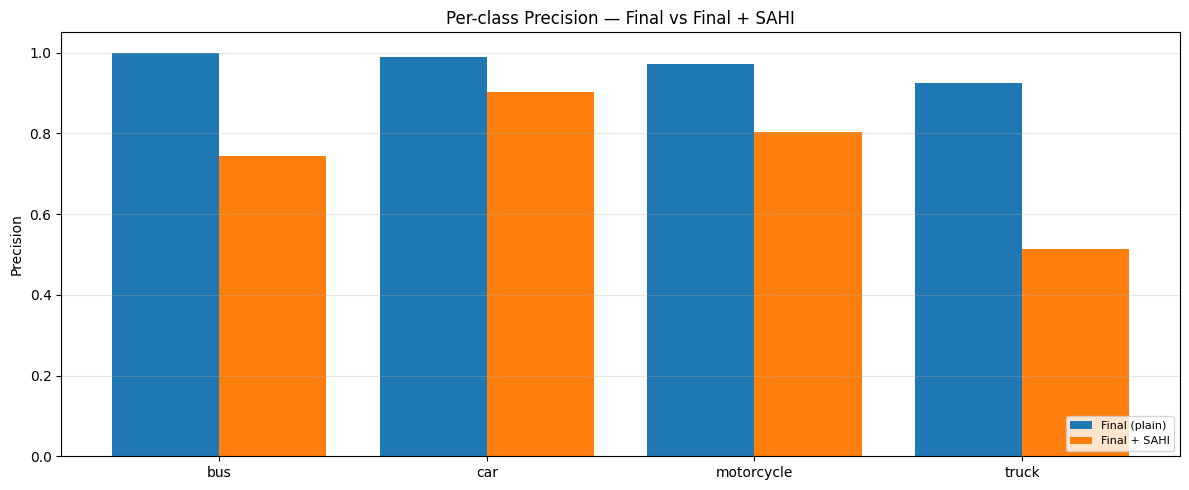

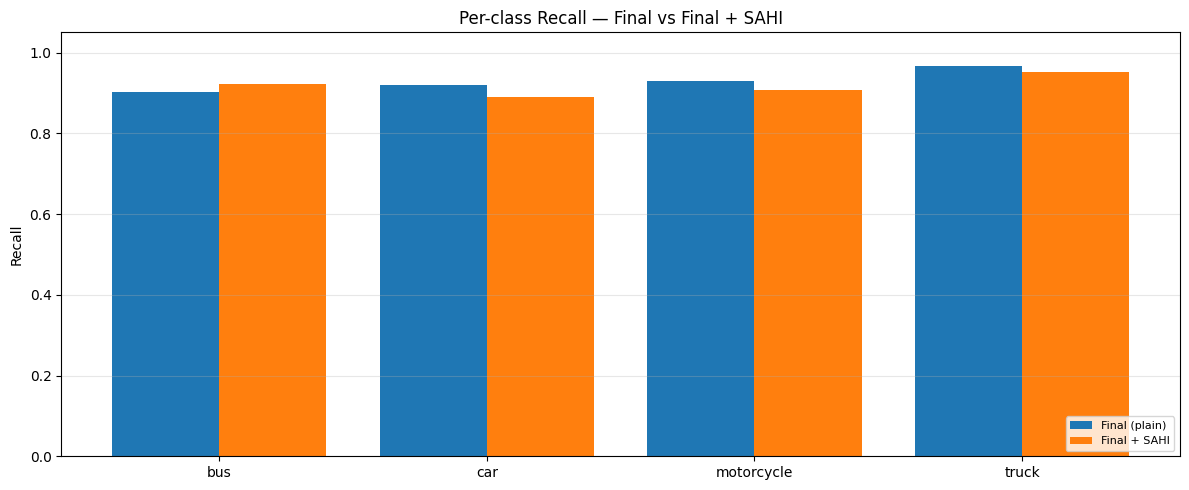

In [28]:
final_per_class = per_class_by_model['Final (Medium+Extra)'][['class', 'Precision', 'Recall']]
sahi_per_class  = df_sahi_per_class[['class', 'Precision', 'Recall']]

ablation_per_class = {
    'Final (plain)': final_per_class,
    'Final + SAHI':  sahi_per_class,
}

plot_grouped_per_class(ablation_per_class, 'Precision',
    'Per-class Precision — Final vs Final + SAHI')
plot_grouped_per_class(ablation_per_class, 'Recall',
    'Per-class Recall — Final vs Final + SAHI')

## Detection examples: Baseline vs Final

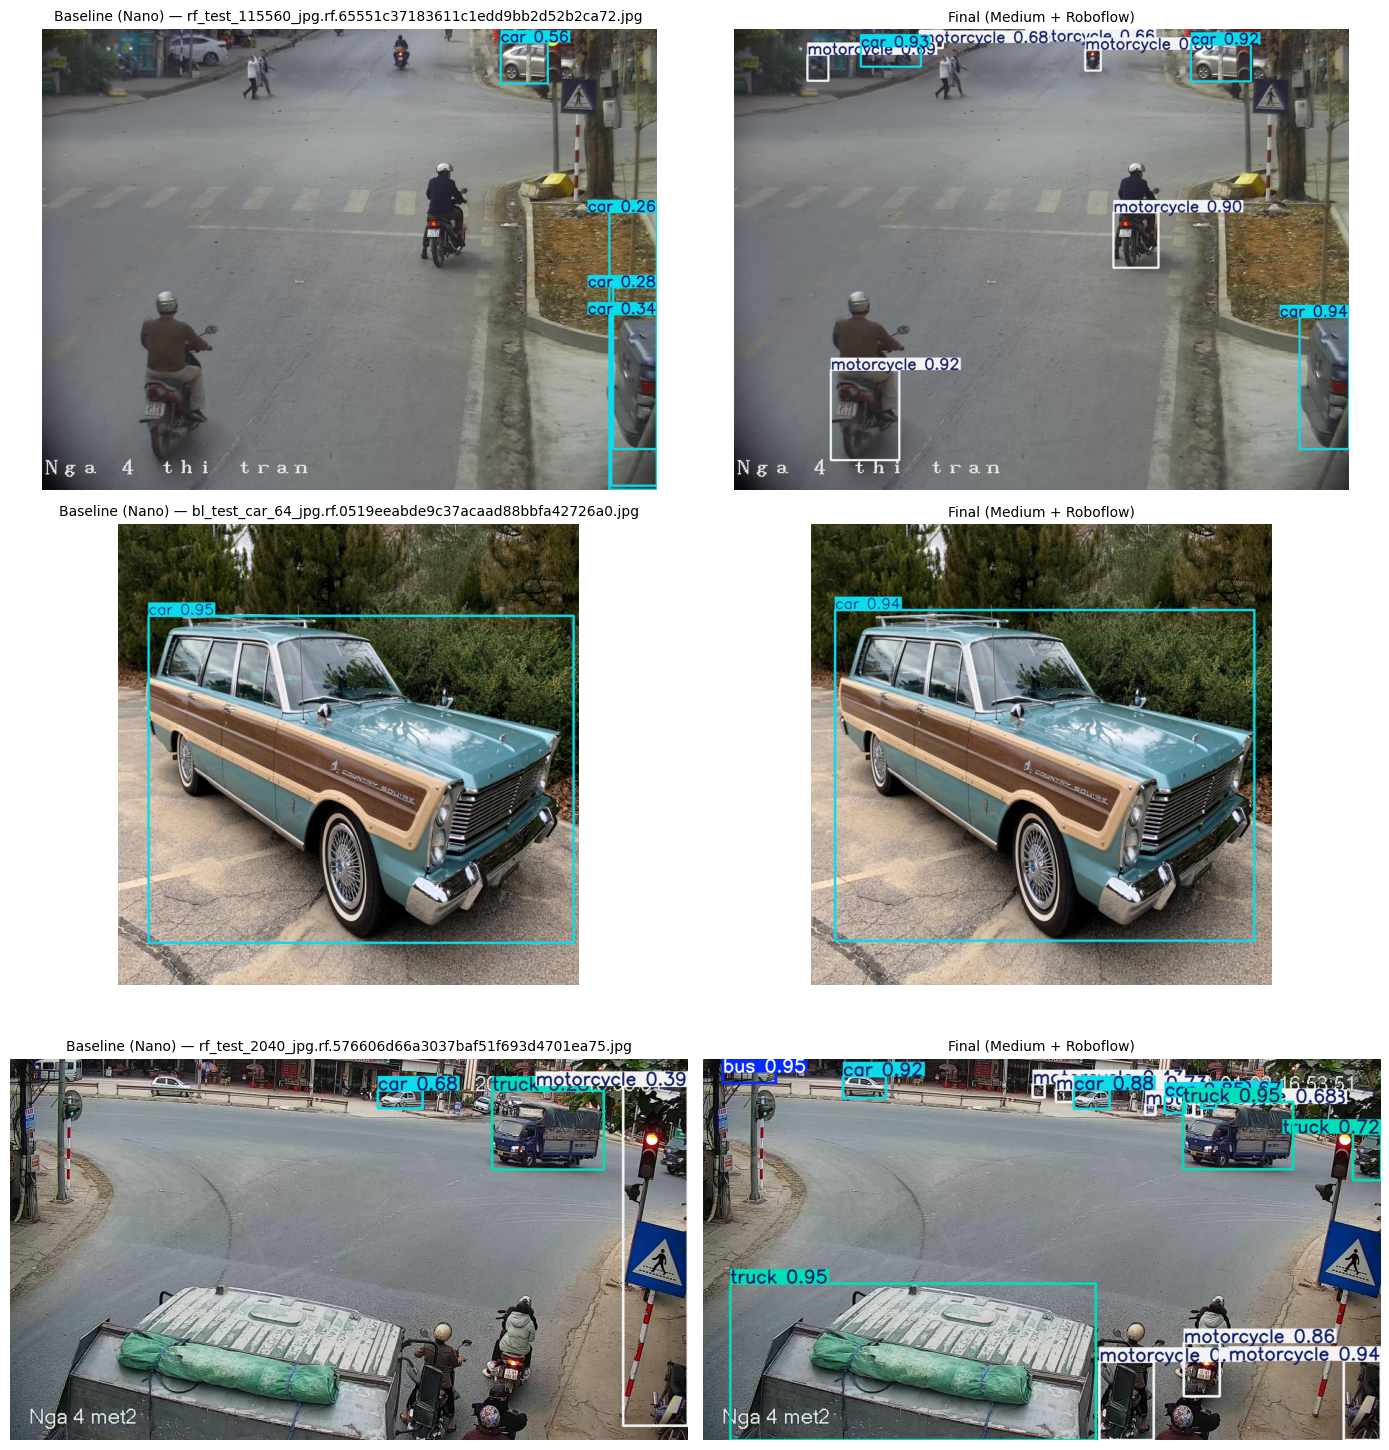

In [29]:
sample_imgs = random.Random(7).sample(test_images, min(3, len(test_images)))

model_b = YOLO(WEIGHTS_BASELINE)
model_f = YOLO(WEIGHTS_FINAL)

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(14, 5 * len(sample_imgs)))
if len(sample_imgs) == 1:
    axes = np.array([axes])

for i, img_path in enumerate(sample_imgs):
    r_b = model_b.predict(img_path, verbose=False, conf=0.25, device=DEVICE)[0]
    r_f = model_f.predict(img_path, verbose=False, conf=0.25, device=DEVICE)[0]

    axes[i, 0].imshow(r_b.plot()[..., ::-1])
    axes[i, 0].set_title(f'Baseline (Nano) — {os.path.basename(img_path)}', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(r_f.plot()[..., ::-1])
    axes[i, 1].set_title('Final (Medium + Roboflow)', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout(); plt.show()

## Summary

This is an evaluation-only notebook: no model was trained here — all four `best.pt`
files were loaded from Drive and only metrics, charts, and SAHI inference were produced.

**Recommended model:** `Final (YOLOv8m on the balanced expanded dataset)`. SAHI is an
inference-time technique reported separately as an ablation against the same weights.

Artifacts written:

- `runs/trained_models_comparison.csv` — overall metrics, 4 trained models
- `runs/sahi_ablation.csv`             — Final vs Final + SAHI